# 13. Evaluating Anomaly Detection Without Clean Labels

Most anomaly-detection projects do not begin with a clean benchmark. Alerts are reviewed selectively, incident tickets arrive late, quiet failures are under-labeled, and many strange observations are benign changes in product, seasonality, instrumentation, or customer mix.

This notebook treats evaluation as a decision-science problem. Instead of asking only “What is the AUC?”, we ask what evidence is available, how biased that evidence may be, and whether the detector is good enough for a specific review budget, incident-response workflow, or monitoring policy.


## Learning Objectives

By the end of this notebook, you should be able to:

- Explain why clean labels are rare in anomaly-detection deployments.
- Compute rank-based metrics such as precision-at-budget and recall-at-budget when full labels are available for simulation or benchmark analysis.
- Diagnose how delayed tickets and selective analyst review can distort apparent detector quality.
- Use random audits to estimate alert precision with less selection bias.
- Use synthetic injections to test whether detectors are sensitive to known failure modes.
- Evaluate detector stability under score perturbations and retraining noise.
- Compare detectors using operational utility rather than a single abstract metric.


## 1. Why Evaluation Is Hard

In ordinary supervised learning, the evaluation set contains labels for all observations. In anomaly detection, the evaluation set often contains only fragments of truth.

| Evidence source | What it tells us | What can go wrong |
|---|---|---|
| Incident tickets | Confirmed serious events | Missing quiet failures, delayed reporting, severity bias |
| Analyst-reviewed alerts | Whether reviewed alerts were useful | Review is usually selected by the old detector, so it is biased |
| Random audit labels | Less biased estimate of alert quality | Expensive and often small |
| Synthetic injections | Whether known failure modes are detectable | Injections may not match real anomalies |
| Historical benchmarks | Reproducible comparison | Benchmark labels may not match current operations |
| Stability checks | Whether rankings are robust | Stable detectors can still be wrong |

The correct question is not “Do we have the true precision?” The correct question is “What can we infer from the evidence we have, and what decision is still risky?”


## 2. Mathematical Setup

Let each monitored object have an anomaly score $s_i$, where larger values are more suspicious. If clean labels were available, $y_i = 1$ would indicate a true anomaly and $y_i = 0$ would indicate a normal case.

For a review budget of $k$, define the top-$k$ alert set as

$$
A_k = \{i : s_i \text{ is among the } k \text{ largest scores}\}.
$$

Precision at budget is

$$
\mathrm{Precision@}k = \frac{\sum_i y_i I(i \in A_k)}{k}.
$$

Recall at budget is

$$
\mathrm{Recall@}k = \frac{\sum_i y_i I(i \in A_k)}{\sum_i y_i}.
$$

In a real deployment, $y_i$ is often unavailable. We may instead observe a proxy label $z_i$, such as an incident ticket, or an audit indicator $r_i$ showing whether an analyst reviewed the item. If reviewed items are selected by the detector itself, then

$$
P(r_i = 1 \mid s_i, y_i) \neq P(r_i = 1),
$$

and naive evaluation on reviewed items can be biased. A random audit sample is valuable because it makes review probability less dependent on the model score.


## 3. Evaluation Evidence Ladder

A practical evaluation plan usually combines several imperfect signals.

| Evaluation layer | Question | Typical output |
|---|---|---|
| Full-label benchmark or simulation | What would we see if truth were known? | AUC, average precision, precision-at-budget |
| Delayed operational labels | Do incident tickets agree with scores? | Proxy-label precision and recall |
| Random audit | How many alerts are truly useful under a review budget? | Estimated precision with uncertainty |
| Synthetic injection | Can the detector catch known failure modes? | Capture rate by injected scenario |
| Stability analysis | Are top alerts reproducible across reruns? | Rank correlation and top-k overlap |
| Utility analysis | Which detector best supports the decision? | Expected benefit after review cost |

Goix (2016) emphasizes that unsupervised anomaly detectors often produce scores rather than only binary labels, and that evaluation without labels requires different criteria than ordinary ROC or precision-recall curves. Iwata et al. (2020) discuss the practical difficulty of exact anomaly labels and formalize settings with inexact labels. These ideas motivate the workflow below.


In [1]:
# Section focus: 3. Evaluation Evidence Ladder.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

import sys
import warnings
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score

repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'notebooks' / '_shared' / 'display.py').exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from notebooks._shared.display import smart_display

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['legend.fontsize'] = 8
plt.rcParams['legend.title_fontsize'] = 8
pd.set_option('display.max_columns', 140)

RANDOM_SEED = 51313
rng = np.random.default_rng(RANDOM_SEED)

PALETTE = {
    'sensitive': '#7c3aed',
    'impact': '#0f766e',
    'stable': '#2563eb',
    'truth': '#111827',
    'proxy': '#f97316',
    'audit': '#dc2626',
    'baseline': '#94a3b8',
    'utility': '#0891b2',
    'release': '#f59e0b',
}

DETECTORS = {
    'sensitive_volume_detector': PALETTE['sensitive'],
    'impact_focused_detector': PALETTE['impact'],
    'stable_ensemble_detector': PALETTE['stable'],
}


def robust_center_scale(values, min_scale=0.20):
    """Carry out the robust center scale step used in the 13. Evaluating Anomaly Detection Without Clean Labels workflow.
    
    Parameters
    ----------
    values : object
        The values setting that controls the robust center scale calculation in this notebook.
    min_scale : object
        The min scale setting that controls the robust center scale calculation in this notebook.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    values = np.asarray(values, dtype=float)
    center = np.nanmedian(values)
    scale = 1.4826 * np.nanmedian(np.abs(values - center))
    return center, max(float(scale), min_scale)


def add_robust_zscores(df, reference_mask, columns):
    """Carry out the add robust zscores step used in the 13. Evaluating Anomaly Detection Without Clean Labels workflow.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    reference_mask : object
        The reference mask setting that controls the add robust zscores calculation in this notebook.
    columns : object
        Column names selected for this calculation.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    out = df.copy()
    params = {}
    for col in columns:
        center, scale = robust_center_scale(out.loc[reference_mask, col])
        out[f'z_{col}'] = (out[col] - center) / scale
        params[col] = {'center': center, 'scale': scale}
    return out, params


def apply_robust_zscores(df, params):
    """Carry out the apply robust zscores step used in the 13. Evaluating Anomaly Detection Without Clean Labels workflow.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    params : object
        The params setting that controls the apply robust zscores calculation in this notebook.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the apply robust zscores calculation.
    """
    out = df.copy()
    for col, p in params.items():
        out[f'z_{col}'] = (out[col] - p['center']) / p['scale']
    return out


def percentile_rank(values):
    """Carry out the percentile rank step used in the 13. Evaluating Anomaly Detection Without Clean Labels workflow.
    
    Parameters
    ----------
    values : object
        The values setting that controls the percentile rank calculation in this notebook.
    
    Returns
    -------
    object
        Intermediate result produced by the percentile rank calculation and reused by later cells.
    """
    values = pd.Series(values)
    return values.rank(method='average', pct=True).to_numpy()


def precision_at_k(y, score, k):
    """Carry out the precision at k step used in the 13. Evaluating Anomaly Detection Without Clean Labels workflow.
    
    Parameters
    ----------
    y : object
        Observed target values used for fitting or evaluation.
    score : object
        Single score, risk value, or diagnostic value used by the decision rule.
    k : object
        Count or size setting for the precision at k calculation.
    
    Returns
    -------
    object
        Intermediate result produced by the precision at k calculation and reused by later cells.
    """
    order = np.argsort(-np.asarray(score))[:k]
    return float(np.mean(np.asarray(y)[order]))


def recall_at_k(y, score, k):
    """Carry out the recall at k step used in the 13. Evaluating Anomaly Detection Without Clean Labels workflow.
    
    Parameters
    ----------
    y : object
        Observed target values used for fitting or evaluation.
    score : object
        Single score, risk value, or diagnostic value used by the decision rule.
    k : object
        Count or size setting for the recall at k calculation.
    
    Returns
    -------
    object
        Intermediate result produced by the recall at k calculation and reused by later cells.
    """
    y = np.asarray(y)
    order = np.argsort(-np.asarray(score))[:k]
    denom = max(y.sum(), 1)
    return float(y[order].sum() / denom)


def wilson_interval(successes, n, z=1.96):
    """Carry out the wilson interval step used in the 13. Evaluating Anomaly Detection Without Clean Labels workflow.
    
    Parameters
    ----------
    successes : object
        The successes setting that controls the wilson interval calculation in this notebook.
    n : object
        Number of observations or simulation units used by the calculation.
    z : object
        Linear predictor or standardized score being transformed by this helper.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    if n == 0:
        return np.nan, np.nan
    p = successes / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half = z * np.sqrt((p * (1 - p) / n) + (z**2 / (4 * n**2))) / denom
    return max(0, center - half), min(1, center + half)


## 4. Synthetic Case: Cloud Job Monitoring

We will simulate a cloud data platform where every row is a production job run. The anomaly detector receives telemetry such as latency, retries, schema mismatch rate, dependency timeouts, payload size, and log-template novelty.

The true anomaly labels are available only because this is a teaching simulation. In a real deployment, the evaluation team would mostly see scores, delayed incident tickets, and analyst review outcomes.

The cloud-job example is designed around a realistic evaluation problem. Jobs can fail loudly, degrade quietly, or look suspicious because workload mix changes. The notebook keeps full synthetic labels so we can compare evaluation strategies, but the simulated ticket labels intentionally behave like production evidence: delayed, selective, and biased toward visible failures.

The experiment studies how detector quality appears under different evidence sources. Full truth, delayed tickets, random audits, and synthetic injections each answer a different question. The goal is to teach students to build an evidence ladder rather than trust one convenient metric.


In [2]:
# Section focus: 4. Synthetic Case: Cloud Job Monitoring.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def simulate_job_runs(seed=RANDOM_SEED, days=60, mean_jobs_per_day=145):
    """Create a simulated job runs data set for the 13. Evaluating Anomaly Detection Without Clean Labels case study.
    
    Parameters
    ----------
    seed : object
        Random seed used to make the simulation reproducible.
    days : object
        Number of days represented in the simulated monitoring window.
    mean_jobs_per_day : object
        The mean jobs per day setting that controls the job runs calculation in this notebook.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(seed)
    start = pd.Timestamp('2026-07-01')
    rows = []
    job_counter = 0
    segments = ['standard', 'enterprise', 'internal', 'new_region']
    segment_probs = [0.62, 0.23, 0.08, 0.07]
    for day in range(days):
        date = start + pd.Timedelta(days=day)
        dow = date.dayofweek
        weekly = 1.12 if dow in [0, 1, 2, 3] else (0.92 if dow == 6 else 1.0)
        n_jobs = int(rng.poisson(mean_jobs_per_day * weekly))
        for _ in range(n_jobs):
            job_counter += 1
            segment = rng.choice(segments, p=segment_probs)
            release_window = 28 <= day <= 31
            maintenance_window = date.dayofweek == 6 and rng.random() < 0.30

            anomaly_kind = 'normal'
            p = rng.random()
            if 21 <= day <= 23 and p < 0.18:
                anomaly_kind = 'service_outage'
            elif 41 <= day <= 43 and segment in ['enterprise', 'internal'] and p < 0.14:
                anomaly_kind = 'data_integrity'
            elif 50 <= day <= 56 and p < 0.055:
                anomaly_kind = 'quiet_degradation'
            elif release_window and p < 0.22:
                anomaly_kind = 'benign_release_shift'

            latency_ms = rng.lognormal(5.35, 0.33)
            retry_count = rng.poisson(0.55 + 0.25 * (segment == 'new_region'))
            error_count = rng.poisson(0.08 + 0.05 * (segment == 'new_region'))
            schema_mismatch_rate = rng.beta(1.3, 65)
            dependency_timeouts = rng.poisson(0.08)
            payload_size_mb = rng.lognormal(2.7 + 0.25 * (segment == 'enterprise'), 0.45)
            novel_template_rate = rng.beta(1.2 + 1.7 * release_window + 0.4 * (segment == 'new_region'), 35)

            if maintenance_window:
                latency_ms *= rng.uniform(1.10, 1.35)
                retry_count += rng.poisson(0.4)
            if anomaly_kind == 'service_outage':
                latency_ms *= rng.uniform(3.0, 5.5)
                retry_count += rng.poisson(5.5)
                error_count += rng.poisson(4.0)
                dependency_timeouts += rng.poisson(3.5)
                novel_template_rate += rng.uniform(0.02, 0.06)
            elif anomaly_kind == 'data_integrity':
                schema_mismatch_rate += rng.uniform(0.12, 0.32)
                payload_size_mb *= rng.uniform(1.35, 2.40)
                error_count += rng.poisson(0.8)
                novel_template_rate += rng.uniform(0.01, 0.05)
            elif anomaly_kind == 'quiet_degradation':
                latency_ms *= rng.uniform(1.55, 2.35)
                retry_count += rng.poisson(1.5)
                dependency_timeouts += rng.poisson(0.8)
            elif anomaly_kind == 'benign_release_shift':
                latency_ms *= rng.uniform(1.15, 1.55)
                retry_count += rng.poisson(0.7)
                novel_template_rate += rng.uniform(0.10, 0.23)

            true_anomaly = anomaly_kind in ['service_outage', 'data_integrity', 'quiet_degradation']
            impact_value = 0.0
            if anomaly_kind == 'service_outage':
                impact_value = rng.uniform(5500, 9500)
            elif anomaly_kind == 'data_integrity':
                impact_value = rng.uniform(10500, 18000)
            elif anomaly_kind == 'quiet_degradation':
                impact_value = rng.uniform(2500, 6500)

            rows.append({
                'job_id': f'J{job_counter:06d}',
                'date': date,
                'day': day,
                'segment': segment,
                'release_window': release_window,
                'maintenance_window': maintenance_window,
                'latency_ms': latency_ms,
                'retry_count': retry_count,
                'error_count': error_count,
                'schema_mismatch_rate': min(schema_mismatch_rate, 0.95),
                'dependency_timeouts': dependency_timeouts,
                'payload_size_mb': payload_size_mb,
                'novel_template_rate': min(novel_template_rate, 0.95),
                'anomaly_kind': anomaly_kind,
                'true_anomaly': true_anomaly,
                'impact_value': impact_value,
            })
    return pd.DataFrame(rows)


def compute_detector_scores(df, params=None, reference_mask=None, seed=RANDOM_SEED, noise=True):
    """Compute detector scores for the 13. Evaluating Anomaly Detection Without Clean Labels workflow.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    params : object
        The params setting that controls the detector scores calculation in this notebook.
    reference_mask : object
        The reference mask setting that controls the detector scores calculation in this notebook.
    seed : object
        Random seed used to make the simulation reproducible.
    noise : object
        The noise setting that controls the detector scores calculation in this notebook.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    feature_cols = ['latency_ms', 'retry_count', 'error_count', 'schema_mismatch_rate', 'dependency_timeouts', 'payload_size_mb', 'novel_template_rate']
    work = df.copy()
    if params is None:
        work, params = add_robust_zscores(work, reference_mask=reference_mask, columns=feature_cols)
    else:
        work = apply_robust_zscores(work, params)

    local_rng = np.random.default_rng(seed)
    jitter_sensitive = local_rng.normal(0, 0.18, len(work)) if noise else 0
    jitter_impact = local_rng.normal(0, 0.12, len(work)) if noise else 0
    jitter_stable = local_rng.normal(0, 0.08, len(work)) if noise else 0

    z = {col: work[f'z_{col}'].clip(lower=-3, upper=8) for col in feature_cols}
    work['sensitive_volume_detector'] = (
        0.28 * z['latency_ms'].clip(lower=0)
        + 0.24 * z['retry_count'].clip(lower=0)
        + 0.24 * z['error_count'].clip(lower=0)
        + 0.18 * z['dependency_timeouts'].clip(lower=0)
        + 0.38 * z['novel_template_rate'].clip(lower=0)
        + 0.18 * (work['segment'].eq('new_region')).astype(float)
        + jitter_sensitive
    )
    work['impact_focused_detector'] = (
        0.18 * z['latency_ms'].clip(lower=0)
        + 0.20 * z['error_count'].clip(lower=0)
        + 0.42 * z['schema_mismatch_rate'].clip(lower=0)
        + 0.26 * z['dependency_timeouts'].clip(lower=0)
        + 0.16 * z['payload_size_mb'].clip(lower=0)
        - 0.18 * z['novel_template_rate'].clip(lower=0)
        + jitter_impact
    )
    work['stable_ensemble_detector'] = (
        0.45 * work['sensitive_volume_detector']
        + 0.55 * work['impact_focused_detector']
        + jitter_stable
    )
    return work, params

jobs = simulate_job_runs()
reference_mask = jobs['day'] < 18
jobs_scored, score_params = compute_detector_scores(jobs, reference_mask=reference_mask, seed=RANDOM_SEED)
monitor = jobs_scored[~reference_mask].copy()
reference = jobs_scored[reference_mask].copy()

summary = jobs_scored.assign(split=np.where(reference_mask, 'reference', 'monitoring')).groupby('split').agg(
    rows=('job_id', 'size'),
    start=('date', 'min'),
    end=('date', 'max'),
    true_anomaly_rate=('true_anomaly', 'mean'),
    mean_latency=('latency_ms', 'mean'),
    mean_error_count=('error_count', 'mean'),
    mean_novel_template_rate=('novel_template_rate', 'mean'),
).reset_index()

kind_summary = monitor.groupby('anomaly_kind').agg(
    jobs=('job_id', 'size'),
    true_anomaly_rate=('true_anomaly', 'mean'),
    mean_impact=('impact_value', 'mean'),
    mean_sensitive_score=('sensitive_volume_detector', 'mean'),
    mean_impact_score=('impact_focused_detector', 'mean'),
).reset_index().sort_values('jobs', ascending=False)

smart_display(summary.style.format({
    'true_anomaly_rate': '{:.2%}',
    'mean_latency': '{:.1f}',
    'mean_error_count': '{:.2f}',
    'mean_novel_template_rate': '{:.2%}',
}))
smart_display(kind_summary.style.format({
    'true_anomaly_rate': '{:.1%}',
    'mean_impact': '${:,.0f}',
    'mean_sensitive_score': '{:.2f}',
    'mean_impact_score': '{:.2f}',
}))


,split,rows,start,end,true_anomaly_rate,mean_latency,mean_error_count,mean_novel_template_rate
0,monitoring,6492,2026-07-19 00:00:00,2026-08-29 00:00:00,2.40%,235.5,0.13,4.16%
1,reference,2800,2026-07-01 00:00:00,2026-07-18 00:00:00,0.00%,224.7,0.08,3.32%


,anomaly_kind,jobs,true_anomaly_rate,mean_impact,mean_sensitive_score,mean_impact_score
2,normal,6192,0.0%,$0,0.97,0.36
0,benign_release_shift,144,0.0%,$0,2.01,0.36
4,service_outage,72,100.0%,"$7,435",7.28,4.82
3,quiet_degradation,69,100.0%,"$4,677",3.20,1.61
1,data_integrity,15,100.0%,"$14,346",1.26,1.83


The reference period is anomaly-free in the simulation, but the monitoring period contains true anomalies and benign shifts. The benign release shift is intentionally important: it looks unusual, but it should not necessarily trigger the same response as a service outage or data-integrity incident.

In real deployment, the evaluator would rarely have the `true_anomaly` column. We will use it only to reveal how different imperfect evaluation strategies behave.


## 5. Full-Label Metrics as an Oracle Baseline

When full labels are available, we can compute conventional metrics. This is useful as an oracle baseline in simulations, controlled benchmarks, or historical periods after complete adjudication.

For anomaly detection, ranking metrics are usually more relevant than accuracy. Accuracy can be misleading because anomalies are rare. A detector that labels everything normal may be highly accurate but useless for incident discovery.


,detector,roc_auc,average_precision,precision_at_100,precision_at_250,recall_at_250
2,stable_ensemble_detector,0.945,0.730,86.0%,47.2%,75.6%
0,sensitive_volume_detector,0.922,0.721,85.0%,45.2%,72.4%
1,impact_focused_detector,0.945,0.693,82.0%,44.8%,71.8%


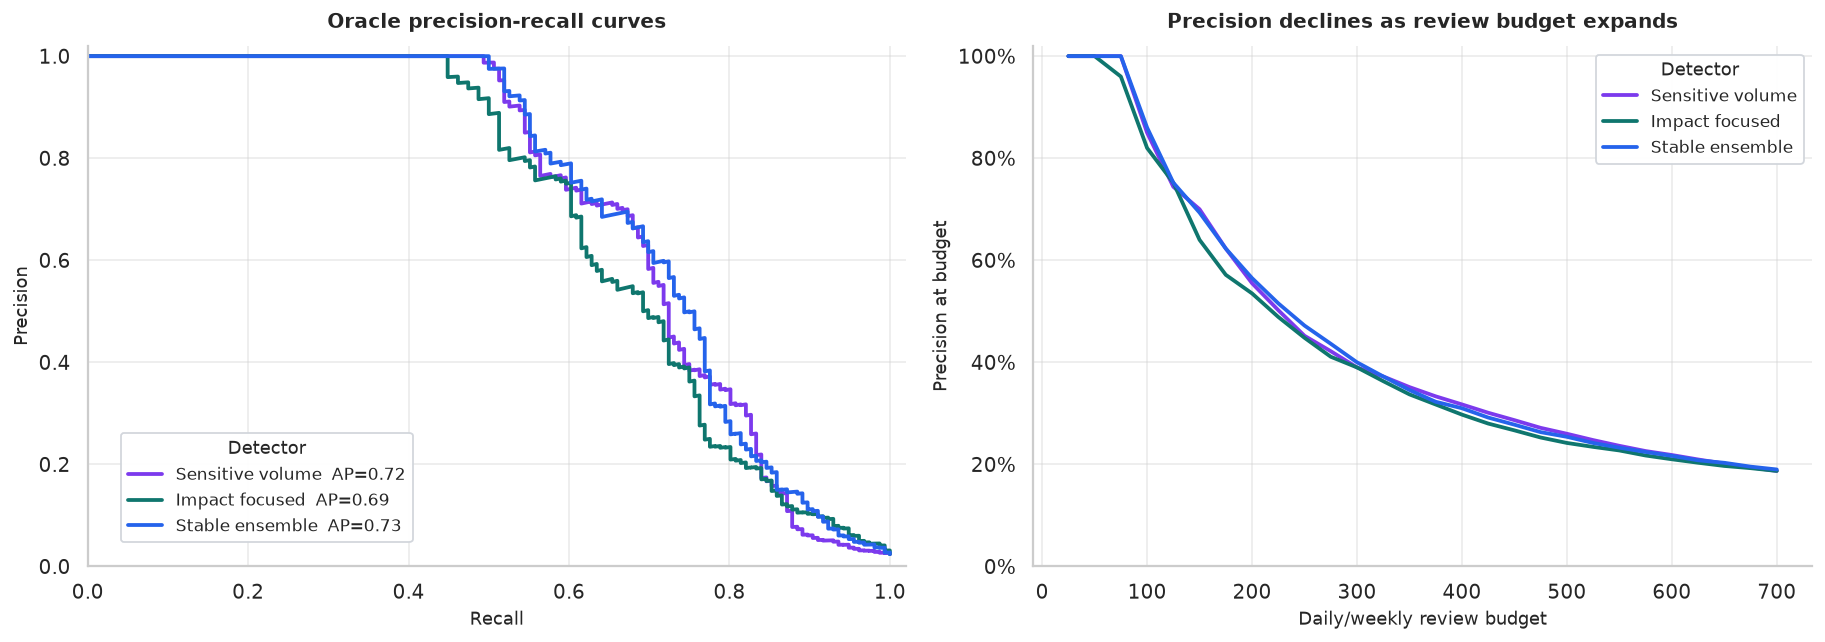

In [3]:
# Section focus: 5. Full-Label Metrics as an Oracle Baseline.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

y_true = monitor['true_anomaly'].astype(int).to_numpy()
metric_rows = []
for detector in DETECTORS:
    score = monitor[detector].to_numpy()
    metric_rows.append({
        'detector': detector,
        'roc_auc': roc_auc_score(y_true, score),
        'average_precision': average_precision_score(y_true, score),
        'precision_at_100': precision_at_k(y_true, score, 100),
        'precision_at_250': precision_at_k(y_true, score, 250),
        'recall_at_250': recall_at_k(y_true, score, 250),
    })
oracle_metrics = pd.DataFrame(metric_rows).sort_values('average_precision', ascending=False)
smart_display(oracle_metrics.style.format({
    'roc_auc': '{:.3f}',
    'average_precision': '{:.3f}',
    'precision_at_100': '{:.1%}',
    'precision_at_250': '{:.1%}',
    'recall_at_250': '{:.1%}',
}))

detector_labels = {
    'sensitive_volume_detector': 'Sensitive volume',
    'impact_focused_detector': 'Impact focused',
    'stable_ensemble_detector': 'Stable ensemble',
}
label_palette = {detector_labels[key]: color for key, color in DETECTORS.items()}

fig, axes = plt.subplots(1, 2, figsize=(14.2, 5.1), gridspec_kw={'width_ratios': [1.05, 1]})
for detector, color in DETECTORS.items():
    precision, recall, _ = precision_recall_curve(y_true, monitor[detector])
    ap = average_precision_score(y_true, monitor[detector])
    axes[0].plot(recall, precision, color=color, linewidth=2.1, label=f'{detector_labels[detector]}  AP={ap:.2f}')
axes[0].set_title('Oracle precision-recall curves', pad=10)
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_xlim(0, 1.02)
axes[0].set_ylim(0, 1.02)
axes[0].legend(
    title='Detector',
    loc='lower left',
    bbox_to_anchor=(0.03, 0.03),
    frameon=True,
    facecolor='white',
    edgecolor='#d1d5db',
    framealpha=0.96,
    fontsize=9.5,
    title_fontsize=10,
)
axes[0].grid(True, alpha=0.35)

budget_grid = np.arange(25, 701, 25)
curves = []
for detector in DETECTORS:
    for budget in budget_grid:
        curves.append({
            'detector': detector_labels[detector],
            'budget': budget,
            'precision_at_budget': precision_at_k(y_true, monitor[detector], budget),
            'recall_at_budget': recall_at_k(y_true, monitor[detector], budget),
        })
budget_curves = pd.DataFrame(curves)
sns.lineplot(data=budget_curves, x='budget', y='precision_at_budget', hue='detector', palette=label_palette, linewidth=2.1, ax=axes[1])
axes[1].set_title('Precision declines as review budget expands', pad=10)
axes[1].set_xlabel('Daily/weekly review budget')
axes[1].set_ylabel('Precision at budget')
axes[1].yaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
axes[1].set_ylim(0, 1.02)
axes[1].grid(True, alpha=0.35)
axes[1].legend(
    title='Detector',
    loc='upper right',
    frameon=True,
    facecolor='white',
    edgecolor='#d1d5db',
    framealpha=0.96,
    fontsize=9.5,
    title_fontsize=10,
)
sns.despine(fig=fig)
plt.tight_layout()
plt.show()


The oracle view says what would be true after perfect adjudication. It is useful for teaching and for synthetic backtests, but it is not the usual production situation.

Notice that a detector can look strong at one review budget and weaker at another. If the team can review only 100 alerts, top-rank precision matters. If the team is conducting broad incident discovery, recall at a larger budget may matter more.


## 6. Delayed Tickets as Proxy Labels

Operational labels often come from incident tickets, escalations, chargebacks, maintenance logs, abuse reports, or customer complaints. These labels are informative but incomplete.

Let $z_i$ be a proxy label. If quiet anomalies are under-reported, then metrics based on $z_i$ can make a detector look worse at finding quiet incidents. If benign release changes create tickets, the proxy can also punish a detector for correctly identifying a change that was operationally expected.


,detector,oracle_average_precision,ticket_proxy_average_precision,oracle_precision_at_250,ticket_proxy_precision_at_250
0,sensitive_volume_detector,0.721,0.600,45.2%,32.8%
1,impact_focused_detector,0.693,0.617,44.8%,34.0%
2,stable_ensemble_detector,0.730,0.617,47.2%,32.8%


,anomaly_kind,jobs,true_anomaly_rate,ticket_label_rate
2,normal,6192,0.0%,0.2%
0,benign_release_shift,144,0.0%,6.9%
4,service_outage,72,100.0%,91.7%
3,quiet_degradation,69,100.0%,33.3%
1,data_integrity,15,100.0%,60.0%


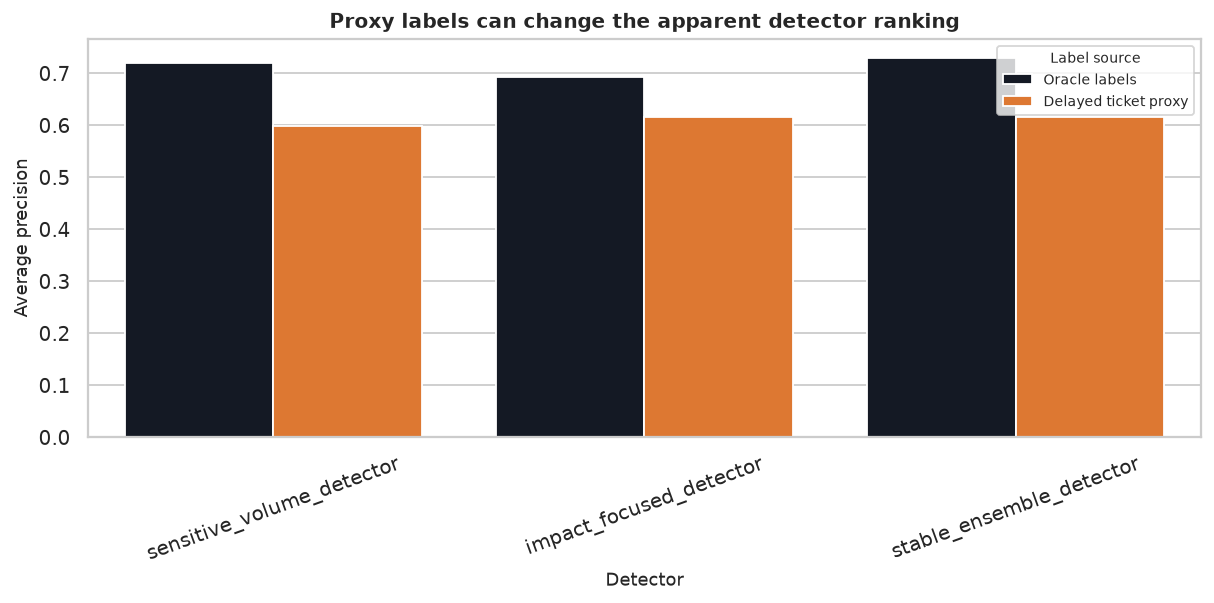

In [4]:
# Section focus: 6. Delayed Tickets as Proxy Labels.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

proxy_rng = np.random.default_rng(RANDOM_SEED + 17)
proxy_prob = np.select(
    [
        monitor['anomaly_kind'].eq('service_outage'),
        monitor['anomaly_kind'].eq('data_integrity'),
        monitor['anomaly_kind'].eq('quiet_degradation'),
        monitor['anomaly_kind'].eq('benign_release_shift'),
    ],
    [0.90, 0.42, 0.24, 0.075],
    default=0.002,
)
monitor['confirmed_ticket_label'] = proxy_rng.random(len(monitor)) < proxy_prob

proxy_rows = []
for detector in DETECTORS:
    proxy_rows.append({
        'detector': detector,
        'oracle_average_precision': average_precision_score(monitor['true_anomaly'], monitor[detector]),
        'ticket_proxy_average_precision': average_precision_score(monitor['confirmed_ticket_label'], monitor[detector]),
        'oracle_precision_at_250': precision_at_k(monitor['true_anomaly'], monitor[detector], 250),
        'ticket_proxy_precision_at_250': precision_at_k(monitor['confirmed_ticket_label'], monitor[detector], 250),
    })
proxy_comparison = pd.DataFrame(proxy_rows)
smart_display(proxy_comparison.style.format({
    'oracle_average_precision': '{:.3f}',
    'ticket_proxy_average_precision': '{:.3f}',
    'oracle_precision_at_250': '{:.1%}',
    'ticket_proxy_precision_at_250': '{:.1%}',
}))

ticket_kind = monitor.groupby('anomaly_kind').agg(
    jobs=('job_id', 'size'),
    true_anomaly_rate=('true_anomaly', 'mean'),
    ticket_label_rate=('confirmed_ticket_label', 'mean'),
).reset_index().sort_values('jobs', ascending=False)
smart_display(ticket_kind.style.format({'true_anomaly_rate': '{:.1%}', 'ticket_label_rate': '{:.1%}'}))

plot_proxy = proxy_comparison.melt(
    id_vars='detector',
    value_vars=['oracle_average_precision', 'ticket_proxy_average_precision'],
    var_name='label_source',
    value_name='average_precision',
)
plot_proxy['label_source'] = plot_proxy['label_source'].map({
    'oracle_average_precision': 'Oracle labels',
    'ticket_proxy_average_precision': 'Delayed ticket proxy',
})
fig, ax = plt.subplots(figsize=(9.5, 4.8))
sns.barplot(data=plot_proxy, x='detector', y='average_precision', hue='label_source', palette=[PALETTE['truth'], PALETTE['proxy']], ax=ax)
ax.set_title('Proxy labels can change the apparent detector ranking')
ax.set_xlabel('Detector')
ax.set_ylabel('Average precision')
ax.tick_params(axis='x', rotation=20)
ax.legend(title='Label source')
plt.tight_layout()
plt.show()


The ticket proxy is useful, but it is not ground truth. In this simulation, service outages are usually ticketed, while data-integrity and quiet-degradation incidents are less consistently labeled. That creates label bias.

This is why evaluation should report the label source. A statement such as “precision is 72%” is incomplete unless we also say “precision against which labels, collected by what process, at what delay?”


## 7. Selective Review and Random Audit

Analyst labels are often collected from reviewed alerts. If the old detector decides what gets reviewed, then the reviewed set is not representative of the monitoring population.

We will compare three estimates of precision for a 5% alert threshold:

1. The oracle precision using hidden truth.
2. A biased estimate using only cases reviewed by an old triage process.
3. A random-audit estimate using a sample selected independently of the detector score.

The random audit is expensive, but it is the cleanest way to learn how alert quality generalizes beyond the old review queue.


,detector,flagged_cases,oracle_precision,biased_review_count,biased_review_precision,random_audit_count,random_audit_precision,random_audit_ci_low,random_audit_ci_high
0,sensitive_volume_detector,325,37.2%,187,52.4%,90,37.8%,28.5%,48.1%
1,impact_focused_detector,325,36.3%,143,66.4%,90,37.8%,28.5%,48.1%
2,stable_ensemble_detector,325,37.2%,173,56.6%,89,39.3%,29.8%,49.7%


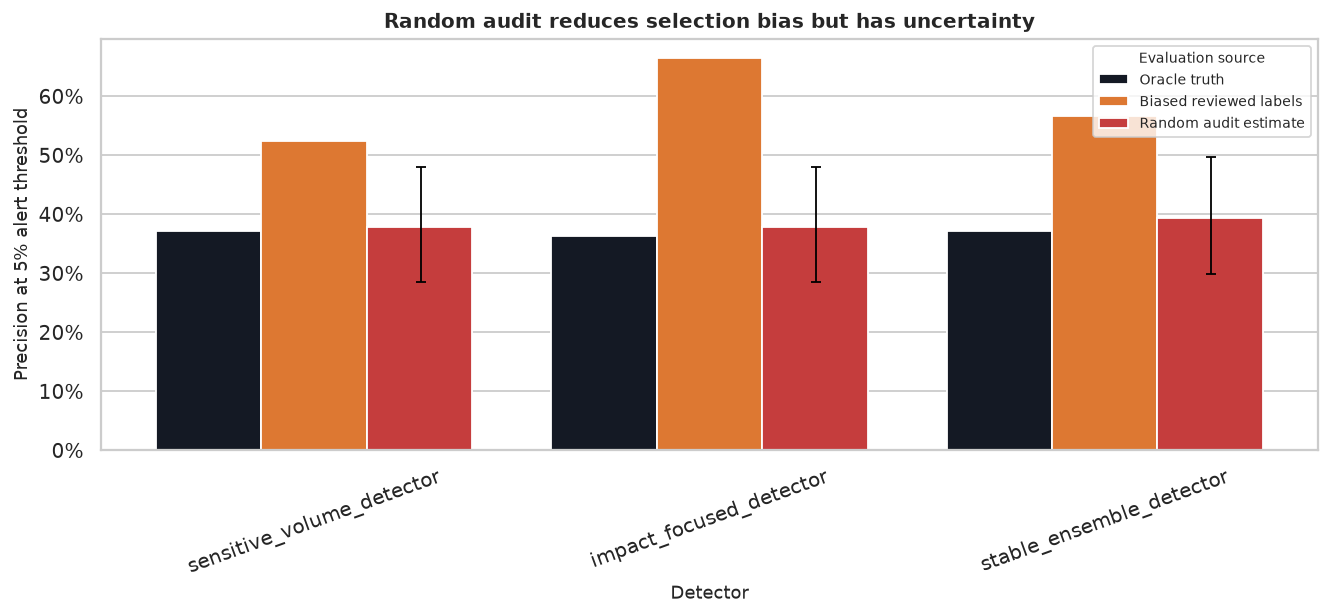

In [5]:
# Section focus: 7. Selective Review and Random Audit.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

audit_rng = np.random.default_rng(RANDOM_SEED + 31)
old_detector_percentile = percentile_rank(monitor['sensitive_volume_detector'])
review_probability = (
    0.012
    + 0.78 * (old_detector_percentile >= 0.965)
    + 0.18 * monitor['segment'].eq('enterprise').astype(float)
    + 0.10 * monitor['confirmed_ticket_label'].astype(float)
)
review_probability = np.clip(review_probability, 0, 0.95)
monitor['biased_reviewed'] = audit_rng.random(len(monitor)) < review_probability

random_audit_n = min(1800, len(monitor))
random_audit_ids = audit_rng.choice(monitor.index.to_numpy(), size=random_audit_n, replace=False)
monitor['random_audit'] = monitor.index.isin(random_audit_ids)

threshold_rate = 0.05
evaluation_rows = []
for detector in DETECTORS:
    threshold_value = monitor[detector].quantile(1 - threshold_rate)
    flagged = monitor[detector] >= threshold_value
    oracle_precision = monitor.loc[flagged, 'true_anomaly'].mean()

    biased_slice = monitor[flagged & monitor['biased_reviewed']]
    random_slice = monitor[flagged & monitor['random_audit']]
    random_successes = int(random_slice['true_anomaly'].sum())
    random_n = len(random_slice)
    lo, hi = wilson_interval(random_successes, random_n)

    evaluation_rows.append({
        'detector': detector,
        'flagged_cases': int(flagged.sum()),
        'oracle_precision': oracle_precision,
        'biased_review_count': len(biased_slice),
        'biased_review_precision': biased_slice['true_anomaly'].mean(),
        'random_audit_count': random_n,
        'random_audit_precision': random_slice['true_anomaly'].mean(),
        'random_audit_ci_low': lo,
        'random_audit_ci_high': hi,
    })
audit_estimates = pd.DataFrame(evaluation_rows)
smart_display(audit_estimates.style.format({
    'oracle_precision': '{:.1%}',
    'biased_review_precision': '{:.1%}',
    'random_audit_precision': '{:.1%}',
    'random_audit_ci_low': '{:.1%}',
    'random_audit_ci_high': '{:.1%}',
}))

plot_audit = audit_estimates.melt(
    id_vars='detector',
    value_vars=['oracle_precision', 'biased_review_precision', 'random_audit_precision'],
    var_name='estimate_type',
    value_name='precision_estimate',
)
plot_audit['estimate_type'] = plot_audit['estimate_type'].map({
    'oracle_precision': 'Oracle truth',
    'biased_review_precision': 'Biased reviewed labels',
    'random_audit_precision': 'Random audit estimate',
})
fig, ax = plt.subplots(figsize=(10.4, 4.9))
sns.barplot(data=plot_audit, x='detector', y='precision_estimate', hue='estimate_type', palette=[PALETTE['truth'], PALETTE['proxy'], PALETTE['audit']], ax=ax)
for _, row in audit_estimates.iterrows():
    x_base = list(audit_estimates['detector']).index(row['detector'])
    ax.errorbar(x_base + 0.27, row['random_audit_precision'], yerr=[[row['random_audit_precision'] - row['random_audit_ci_low']], [row['random_audit_ci_high'] - row['random_audit_precision']]], color='black', capsize=3, linewidth=1)
ax.set_title('Random audit reduces selection bias but has uncertainty')
ax.set_xlabel('Detector')
ax.set_ylabel('Precision at 5% alert threshold')
ax.yaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
ax.tick_params(axis='x', rotation=20)
ax.legend(title='Evaluation source', loc='upper right')
plt.tight_layout()
plt.show()


The biased review estimate answers a narrow question: “Among alerts the old process tended to review, how many were true incidents?” It does not necessarily answer whether a new detector is better.

The random audit estimate is noisier, but conceptually cleaner. If review budget allows, every anomaly-detection deployment should reserve some review capacity for random or stratified audit. Without that, the team may simply reinforce the old detector’s blind spots.


## 8. Synthetic Injection Tests

Synthetic injections do not prove real-world performance, but they answer a useful engineering question: “Can the detector respond to failure modes we already know how to describe?”

We take reference-period normal jobs, perturb them into known failure modes, rescore them, and measure capture rate above a fixed threshold.

The injection test creates controlled failures inside otherwise normal reference jobs. This is useful because an organization can often describe failure modes before it has many labeled examples of them. For example, engineers may know what a dependency-timeout pattern looks like even if only a few incidents have been confirmed.

The experiment should be read as a detector responsiveness check. It does not replace live evaluation, but it tells us whether the score reacts to known failure mechanisms at all. If a detector misses injected failures, it is unlikely to be reliable in production without redesign.


detector,impact_focused_detector,sensitive_volume_detector,stable_ensemble_detector
injection_scenario,,,
benign_release_shift,0.6%,5.0%,2.2%
data_integrity,17.4%,5.3%,13.4%
quiet_degradation,20.6%,32.4%,31.6%
service_outage,99.6%,100.0%,99.8%


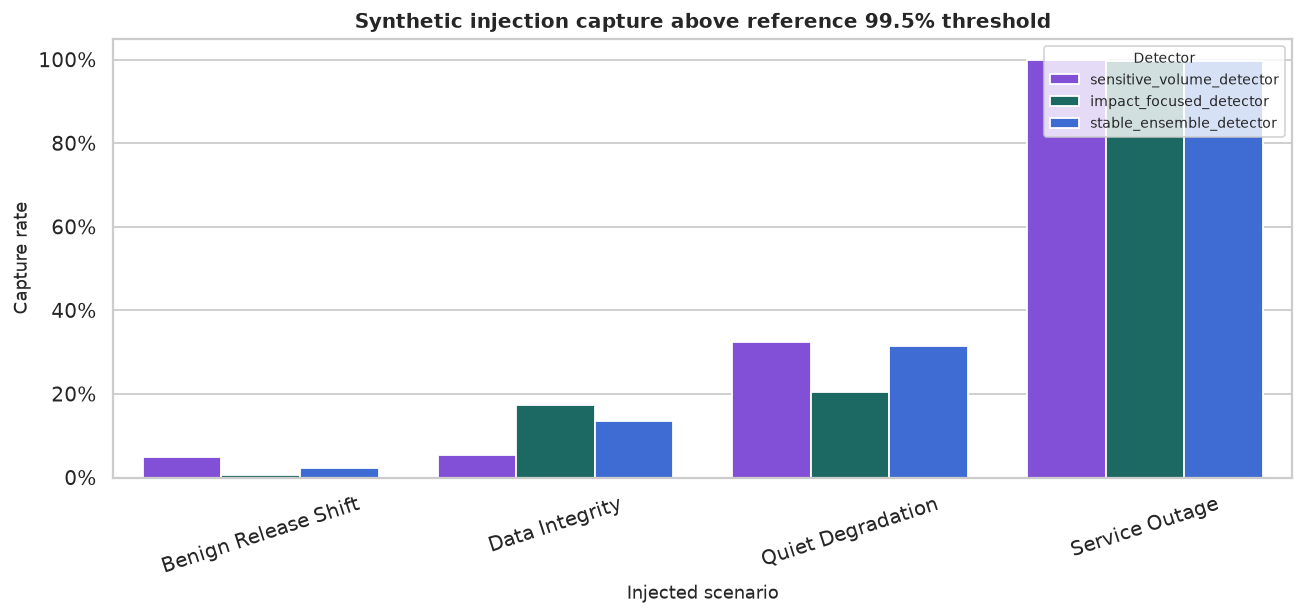

In [6]:
# Section focus: 8. Synthetic Injection Tests.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def inject_failure_modes(base_rows, seed=RANDOM_SEED + 77):
    """Carry out the inject failure modes step used in the 13. Evaluating Anomaly Detection Without Clean Labels workflow.
    
    Parameters
    ----------
    base_rows : object
        Single observation or record being converted, scored, or summarized.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        Intermediate result produced by the inject failure modes calculation and reused by later cells.
    """
    rng = np.random.default_rng(seed)
    injected = []
    scenarios = ['service_outage', 'data_integrity', 'quiet_degradation', 'benign_release_shift']
    for scenario in scenarios:
        tmp = base_rows.sample(n=min(900, len(base_rows)), random_state=seed + len(injected)).copy()
        tmp['injection_scenario'] = scenario
        if scenario == 'service_outage':
            tmp['latency_ms'] *= rng.uniform(3.0, 5.0, len(tmp))
            tmp['retry_count'] += rng.poisson(5.0, len(tmp))
            tmp['error_count'] += rng.poisson(4.0, len(tmp))
            tmp['dependency_timeouts'] += rng.poisson(3.0, len(tmp))
            tmp['novel_template_rate'] += rng.uniform(0.02, 0.06, len(tmp))
        elif scenario == 'data_integrity':
            tmp['schema_mismatch_rate'] += rng.uniform(0.12, 0.30, len(tmp))
            tmp['payload_size_mb'] *= rng.uniform(1.3, 2.2, len(tmp))
            tmp['error_count'] += rng.poisson(0.8, len(tmp))
        elif scenario == 'quiet_degradation':
            tmp['latency_ms'] *= rng.uniform(1.55, 2.25, len(tmp))
            tmp['retry_count'] += rng.poisson(1.4, len(tmp))
            tmp['dependency_timeouts'] += rng.poisson(0.7, len(tmp))
        elif scenario == 'benign_release_shift':
            tmp['latency_ms'] *= rng.uniform(1.15, 1.50, len(tmp))
            tmp['retry_count'] += rng.poisson(0.7, len(tmp))
            tmp['novel_template_rate'] += rng.uniform(0.10, 0.22, len(tmp))
        tmp['schema_mismatch_rate'] = tmp['schema_mismatch_rate'].clip(0, 0.95)
        tmp['novel_template_rate'] = tmp['novel_template_rate'].clip(0, 0.95)
        injected.append(tmp)
    return pd.concat(injected, ignore_index=True)

injected = inject_failure_modes(reference)
injected_scored, _ = compute_detector_scores(injected, params=score_params, seed=RANDOM_SEED + 78, noise=False)

capture_rows = []
for detector in DETECTORS:
    threshold_value = reference[detector].quantile(0.995)
    for scenario, group in injected_scored.groupby('injection_scenario'):
        capture_rows.append({
            'detector': detector,
            'injection_scenario': scenario,
            'reference_threshold': threshold_value,
            'capture_rate': (group[detector] >= threshold_value).mean(),
            'mean_score': group[detector].mean(),
        })
injection_results = pd.DataFrame(capture_rows)
smart_display(injection_results.pivot(index='injection_scenario', columns='detector', values='capture_rate').style.format('{:.1%}'))

fig, ax = plt.subplots(figsize=(10.2, 4.9))
plot_injection = injection_results.copy()
plot_injection['scenario_label'] = plot_injection['injection_scenario'].str.replace('_', ' ').str.title()
sns.barplot(data=plot_injection, x='scenario_label', y='capture_rate', hue='detector', palette=DETECTORS, ax=ax)
ax.set_title('Synthetic injection capture above reference 99.5% threshold')
ax.set_xlabel('Injected scenario')
ax.set_ylabel('Capture rate')
ax.yaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
ax.tick_params(axis='x', rotation=18)
ax.legend(title='Detector', loc='upper right')
plt.tight_layout()
plt.show()


Injection tests reveal detector sensitivity by scenario. A detector that is excellent for service outages may be weak for data-integrity failures. A detector that reacts strongly to release novelty may flood review teams during harmless deployments.

The important governance point: synthetic injections are not final proof. They are challenge tests. They should be treated like unit tests for monitoring logic, not like a full estimate of real-world precision.


## 9. Stability and Reproducibility

A detector can perform well on one run and still be operationally fragile. If small data changes or retraining noise reshuffle the top alerts, analysts may lose trust.

We measure two stability quantities:

$$
\mathrm{TopKOverlap} = \frac{|A_k^{(0)} \cap A_k^{(b)}|}{k},
$$

where $A_k^{(0)}$ is the original top-$k$ set and $A_k^{(b)}$ is the top-$k$ set after perturbation $b$.

We also compute Spearman rank correlation between the original and perturbed scores.


,detector,mean_top_250_overlap,p10_top_250_overlap,mean_spearman,p10_spearman
0,impact_focused_detector,92.4%,91.2%,0.899,0.897
1,sensitive_volume_detector,89.9%,88.8%,0.962,0.962
2,stable_ensemble_detector,95.2%,94.4%,0.984,0.984


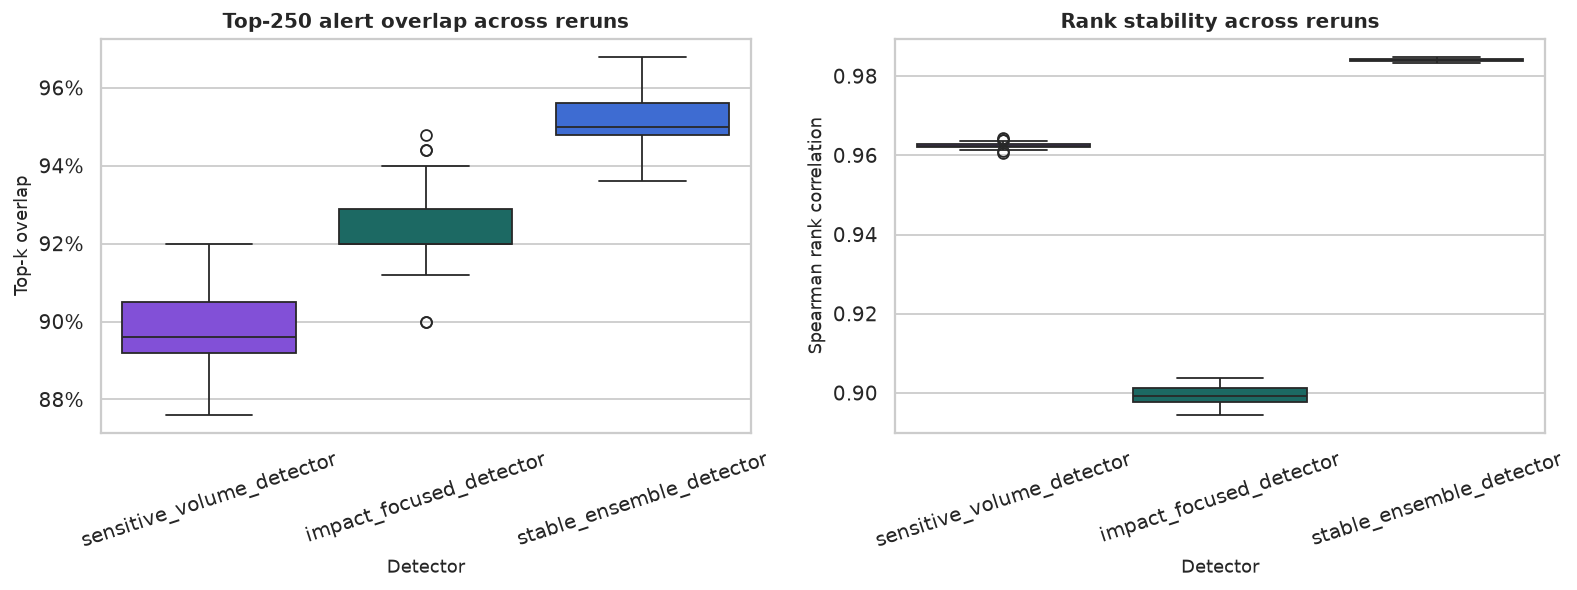

In [7]:
# Section focus: 9. Stability and Reproducibility.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

stability_rng = np.random.default_rng(RANDOM_SEED + 101)
k_stability = 250
stability_rows = []
noise_scale = {
    'sensitive_volume_detector': 0.22,
    'impact_focused_detector': 0.14,
    'stable_ensemble_detector': 0.09,
}
for detector in DETECTORS:
    base_score = monitor[detector].to_numpy()
    base_top = set(monitor.iloc[np.argsort(-base_score)[:k_stability]]['job_id'])
    for run in range(40):
        perturbed = base_score + stability_rng.normal(0, noise_scale[detector], len(base_score))
        perturbed_top = set(monitor.iloc[np.argsort(-perturbed)[:k_stability]]['job_id'])
        overlap = len(base_top & perturbed_top) / k_stability
        rho = spearmanr(base_score, perturbed).correlation
        stability_rows.append({
            'detector': detector,
            'rerun': run,
            'top_250_overlap': overlap,
            'spearman_rank_correlation': rho,
        })
stability = pd.DataFrame(stability_rows)
stability_summary = stability.groupby('detector').agg(
    mean_top_250_overlap=('top_250_overlap', 'mean'),
    p10_top_250_overlap=('top_250_overlap', lambda x: np.quantile(x, 0.10)),
    mean_spearman=('spearman_rank_correlation', 'mean'),
    p10_spearman=('spearman_rank_correlation', lambda x: np.quantile(x, 0.10)),
).reset_index()
smart_display(stability_summary.style.format({
    'mean_top_250_overlap': '{:.1%}',
    'p10_top_250_overlap': '{:.1%}',
    'mean_spearman': '{:.3f}',
    'p10_spearman': '{:.3f}',
}))

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.7))
sns.boxplot(data=stability, x='detector', y='top_250_overlap', hue='detector', palette=DETECTORS, dodge=False, legend=False, ax=axes[0])
axes[0].set_title('Top-250 alert overlap across reruns')
axes[0].set_xlabel('Detector')
axes[0].set_ylabel('Top-k overlap')
axes[0].yaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
axes[0].tick_params(axis='x', rotation=18)

sns.boxplot(data=stability, x='detector', y='spearman_rank_correlation', hue='detector', palette=DETECTORS, dodge=False, legend=False, ax=axes[1])
axes[1].set_title('Rank stability across reruns')
axes[1].set_xlabel('Detector')
axes[1].set_ylabel('Spearman rank correlation')
axes[1].tick_params(axis='x', rotation=18)
plt.tight_layout()
plt.show()


Stability does not guarantee correctness. It tells us whether the detector is reproducible enough for operations. A highly unstable detector can still find real anomalies, but it may be difficult to explain why the queue changes from one run to the next.

For production use, stability should be reported alongside precision and recall. If two detectors have similar utility, the more stable one may be preferable because it creates less operational churn.


## 10. Decision Utility Under Review Budgets

A detector should be evaluated against the decision it supports. Suppose reviewing an alert costs money and analyst attention. Missing a real incident has opportunity cost. A simple utility model is

$$
U(A_k) = \sum_{i \in A_k} v_i y_i - c k,
$$

where $v_i$ is the incident value recovered by reviewing item $i$, $y_i$ is the true anomaly indicator, and $c$ is the review cost per item.

This is a simplified model. In practice, $v_i$ can represent avoided downtime, prevented fraud, reduced safety risk, protected reputation, or regulatory exposure.


,detector,budget,true_hits,precision,recall,recovered_value,review_spend,net_utility,benign_release_reviews
12,impact_focused_detector,650,128,19.7%,82.1%,"$906,212","$81,250","$824,962",17
20,stable_ensemble_detector,900,136,15.1%,87.2%,"$906,735","$112,500","$794,235",46
4,sensitive_volume_detector,400,127,31.8%,81.4%,"$805,315","$50,000","$755,315",35


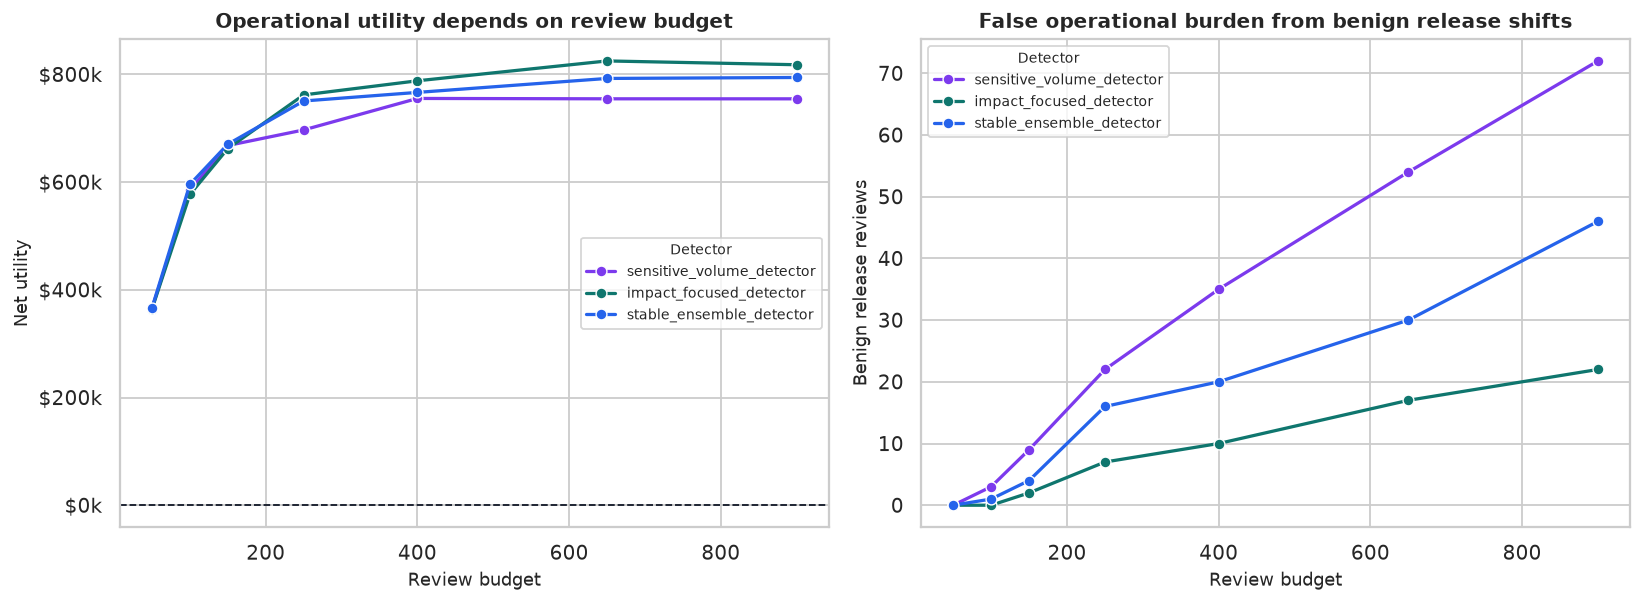

In [8]:
# Section focus: 10. Decision Utility Under Review Budgets.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

review_cost = 125
budget_values = [50, 100, 150, 250, 400, 650, 900]
utility_rows = []
for detector in DETECTORS:
    ordered = monitor.sort_values(detector, ascending=False).copy()
    for budget in budget_values:
        chosen = ordered.head(budget)
        true_hits = int(chosen['true_anomaly'].sum())
        recovered_value = chosen['impact_value'].sum()
        review_spend = review_cost * budget
        benign_release_reviews = int(chosen['anomaly_kind'].eq('benign_release_shift').sum())
        utility_rows.append({
            'detector': detector,
            'budget': budget,
            'true_hits': true_hits,
            'precision': true_hits / budget,
            'recall': true_hits / max(monitor['true_anomaly'].sum(), 1),
            'recovered_value': recovered_value,
            'review_spend': review_spend,
            'net_utility': recovered_value - review_spend,
            'benign_release_reviews': benign_release_reviews,
        })
utility = pd.DataFrame(utility_rows)
best_by_detector = utility.loc[utility.groupby('detector')['net_utility'].idxmax()].sort_values('net_utility', ascending=False)
smart_display(best_by_detector.style.format({
    'precision': '{:.1%}',
    'recall': '{:.1%}',
    'recovered_value': '${:,.0f}',
    'review_spend': '${:,.0f}',
    'net_utility': '${:,.0f}',
}))

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))
sns.lineplot(data=utility, x='budget', y='net_utility', hue='detector', palette=DETECTORS, marker='o', linewidth=1.8, ax=axes[0])
axes[0].axhline(0, color=PALETTE['truth'], linestyle='--', linewidth=1.0)
axes[0].set_title('Operational utility depends on review budget')
axes[0].set_xlabel('Review budget')
axes[0].set_ylabel('Net utility')
axes[0].yaxis.set_major_formatter(lambda x, pos: f'${x/1000:.0f}k')
axes[0].legend(title='Detector')

sns.lineplot(data=utility, x='budget', y='benign_release_reviews', hue='detector', palette=DETECTORS, marker='o', linewidth=1.8, ax=axes[1])
axes[1].set_title('False operational burden from benign release shifts')
axes[1].set_xlabel('Review budget')
axes[1].set_ylabel('Benign release reviews')
axes[1].legend(title='Detector')
plt.tight_layout()
plt.show()


Utility can reverse a ranking based on average precision alone. If data-integrity failures carry high value, a detector that finds fewer but more important incidents can be preferred. If analyst review is scarce, a detector that floods the queue with benign release shifts may be unacceptable even if it has good recall.

The point is not that this utility function is perfect. The point is that anomaly detection is deployed to support a decision, and the evaluation should reflect that decision.


## 11. Evaluation Scorecard

A useful model-review artifact combines several evidence sources. The scorecard below is the kind of table I would want before launching a detector into production.


In [9]:
# Section focus: 11. Evaluation Scorecard.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

scorecard_rows = []
for detector in DETECTORS:
    oracle = oracle_metrics[oracle_metrics['detector'].eq(detector)].iloc[0]
    audit = audit_estimates[audit_estimates['detector'].eq(detector)].iloc[0]
    stable = stability_summary[stability_summary['detector'].eq(detector)].iloc[0]
    utility_best = best_by_detector[best_by_detector['detector'].eq(detector)].iloc[0]
    detector_injections = injection_results[injection_results['detector'].eq(detector)]
    failure_scenarios = ['service_outage', 'data_integrity', 'quiet_degradation']
    injection_min = detector_injections[detector_injections['injection_scenario'].isin(failure_scenarios)]['capture_rate'].min()
    benign_release_capture = detector_injections.loc[
        detector_injections['injection_scenario'].eq('benign_release_shift'), 'capture_rate'
    ].iloc[0]
    scorecard_rows.append({
        'detector': detector,
        'oracle_ap': oracle['average_precision'],
        'random_audit_precision_5pct': audit['random_audit_precision'],
        'random_audit_ci': f"{audit['random_audit_ci_low']:.0%} to {audit['random_audit_ci_high']:.0%}",
        'minimum_failure_injection_capture': injection_min,
        'benign_release_capture': benign_release_capture,
        'mean_top_250_overlap': stable['mean_top_250_overlap'],
        'best_budget': int(utility_best['budget']),
        'best_net_utility': utility_best['net_utility'],
        'main_risk': {
            'sensitive_volume_detector': 'Over-alerts on benign release and novelty shifts',
            'impact_focused_detector': 'May miss low-severity degradation and volume-only events',
            'stable_ensemble_detector': 'Compromise model may be less optimal for any one incident type',
        }[detector],
    })
scorecard = pd.DataFrame(scorecard_rows).sort_values('best_net_utility', ascending=False)
smart_display(scorecard.style.format({
    'oracle_ap': '{:.3f}',
    'random_audit_precision_5pct': '{:.1%}',
    'minimum_failure_injection_capture': '{:.1%}',
    'benign_release_capture': '{:.1%}',
    'mean_top_250_overlap': '{:.1%}',
    'best_net_utility': '${:,.0f}',
}), max_width='460px')


,detector,oracle_ap,random_audit_precision_5pct,random_audit_ci,minimum_failure_injection_capture,benign_release_capture,mean_top_250_overlap,best_budget,best_net_utility,main_risk
1,impact_focused_detector,0.693,37.8%,28% to 48%,17.4%,0.6%,92.4%,650,"$824,962",May miss low-severity degradation and volume-only events
2,stable_ensemble_detector,0.730,39.3%,30% to 50%,13.4%,2.2%,95.2%,900,"$794,235",Compromise model may be less optimal for any one incident type
0,sensitive_volume_detector,0.721,37.8%,28% to 48%,5.3%,5.0%,89.9%,400,"$755,315",Over-alerts on benign release and novelty shifts


The scorecard makes a crucial distinction: evidence is plural. A detector can have strong oracle metrics, weak random-audit evidence, excellent failure-scenario injection capture, poor stability, or attractive utility under one budget but not another.

The injection columns also separate true-failure capture from benign-release capture. Low benign-release capture can be acceptable when release shifts are expected and documented, because the detector is less likely to turn planned deployments into incidents.

For a high-stakes decision system, the launch decision should not rest on a single number. It should rest on converging evidence and a clear statement of remaining risk.


## 12. Decision Memo

The final recommendation should be explicit about evidence quality and launch conditions.


In [10]:
recommended = scorecard.iloc[0]
decision_memo = pd.DataFrame([
    {
        'decision_question': 'Which detector should be promoted first?',
        'evidence': f"{recommended['detector']} has the highest utility in this simulation while maintaining usable audit precision and stability.",
        'recommendation': 'Promote as a shadow-mode candidate, not as a fully autonomous incident trigger.',
    },
    {
        'decision_question': 'What evidence is not enough by itself?',
        'evidence': 'Delayed tickets under-label quiet incidents and biased analyst reviews inherit the old triage policy.',
        'recommendation': 'Report ticket-proxy metrics separately from random-audit estimates.',
    },
    {
        'decision_question': 'What launch guardrail is required?',
        'evidence': 'Benign release shifts can look anomalous and create avoidable review burden.',
        'recommendation': 'Require release annotations and a suppression policy for expected deployment windows.',
    },
    {
        'decision_question': 'What should the team collect next?',
        'evidence': 'Random audit intervals are informative but still wide for some detectors.',
        'recommendation': 'Reserve a fixed weekly audit budget and stratify it across score bands, segments, and incident types.',
    },
])
smart_display(decision_memo, max_width='520px')


,decision_question,evidence,recommendation
0,Which detector should be promoted first?,impact_focused_detector has the highest utility in this simulation while maintaining usable audit precision and stability.,"Promote as a shadow-mode candidate, not as a fully autonomous incident trigger."
1,What evidence is not enough by itself?,Delayed tickets under-label quiet incidents and biased analyst reviews inherit the old triage policy.,Report ticket-proxy metrics separately from random-audit estimates.
2,What launch guardrail is required?,Benign release shifts can look anomalous and create avoidable review burden.,Require release annotations and a suppression policy for expected deployment windows.
3,What should the team collect next?,Random audit intervals are informative but still wide for some detectors.,"Reserve a fixed weekly audit budget and stratify it across score bands, segments, and incident types."


Treat this result as an alerting diagnostic. In Decision Memo, the important question is whether the score separates real operational risk from routine variation, measurement noise, or known seasonality. When a segment, time window, or service stands out, it should guide triage and root-cause follow-up.


## 13. Key Takeaways

- Full-label metrics are useful in simulations and adjudicated benchmarks, but production labels are often delayed, selective, and incomplete.
- Ticket proxies can be severity-biased and may understate performance on quiet anomalies.
- Analyst-reviewed labels are useful but can be biased by the old detector or by operational triage rules.
- Random audits are expensive but essential for estimating alert quality with less selection bias.
- Synthetic injections test sensitivity to known failure modes, not real-world precision.
- Stability diagnostics measure whether alert rankings are reproducible enough for operations.
- Utility-based evaluation connects detector ranking to the business decision, review budget, and cost of false positives.


## References

- Chandola, V., Banerjee, A., & Kumar, V. (2009). Anomaly detection. *ACM Computing Surveys, 41*(3), 1-58. [https://doi.org/10.1145/1541880.1541882](https://doi.org/10.1145/1541880.1541882)
- Goix, N. (2016). How to evaluate the quality of unsupervised anomaly detection algorithms? *arXiv*. [https://doi.org/10.48550/arxiv.1607.01152](https://doi.org/10.48550/arxiv.1607.01152)
- Iwata, T., Toyoda, M., Tora, S., & Ueda, N. (2020). Anomaly detection with inexact labels. *Machine Learning, 109*(8), 1617-1633. [https://doi.org/10.1007/s10994-020-05880-w](https://doi.org/10.1007/s10994-020-05880-w)
- Pimentel, T., Monteiro, M., Veloso, A., & Ziviani, N. (2020). Deep active learning for anomaly detection. *International Joint Conference on Neural Networks*, 1-8. [https://doi.org/10.1109/ijcnn48605.2020.9206769](https://doi.org/10.1109/ijcnn48605.2020.9206769)
- Vigoya Morales, L. V., López-Vizcaíno, M., Fernández Iglesias, D., & Carneiro Díaz, V. M. (2019). Anomaly detection in IoT: Methods, techniques and tools. *Proceedings, 21*(1), 4. [https://doi.org/10.3390/proceedings2019021004](https://doi.org/10.3390/proceedings2019021004)
